# Vision Transformer (ViT) 图片分类教学案例：从原理到实战

## 深度学习前沿：基于 Caltech101 数据集的 101 类物体识别

本笔记本将带您深入探索 **Vision Transformer (ViT)** —— 这一彻底改变计算机视觉领域（CV）的里程碑式技术。我们将不再依赖传统的卷积操作，而是学习如何将图像视为“单词序列”，利用强大的自注意力机制（Self-Attention）来捕捉图像中的全局信息。

通过本案例，您将完整经历从环境准备、数据管道构建、模型迁移学习到深度性能分析的全过程。


## 问题定义与学习目标

### 1. 什么是 Vision Transformer (ViT)?
Vision Transformer 是由 Google 在 2020 年发表的论文《An Image is Worth 16x16 Words》中提出的。它向我们展示了：**当数据量足够大时，Transformer 架构在计算机视觉任务上可以完全取代卷积神经网络 (CNN)**。

其核心逻辑是将图像处理流程“NLP 化”：
*   **图像分块 (Patchifying)**：将 224x224 的图像分割成 196 个 16x16 的小块。
*   **线性嵌入 (Linear Embedding)**：将每个小块拉平并映射为高维向量。
*   **位置编码 (Positional Encoding)**：为这些向量注入空间位置信息（因为 Transformer 本身是置换不变的）。
*   **Transformer 编码器**：利用多层自注意力机制学习块与块之间的复杂关联。

### 2. 本教学案例的核心目标
1.  **架构深度理解**：对比 CNN 的“局部感受野”与 ViT 的“全局自注意力”，理解为何 ViT 擅长捕捉长距离依赖。
2.  **PyTorch 工业级实践**：掌握使用 `torchvision` 和 `timm` (Torch Image Models) 库构建高效模型的方法。
3.  **迁移学习 (Transfer Learning)**：学习如何利用在大规模数据集（如 ImageNet）上预训练的权重，在小规模数据集（Caltech101）上实现高精度分类。
4.  **全链路评估**：不仅看准确率，还将深入分析混淆矩阵，找出模型在特定类别上的“痛点”。

---


## 1. 环境配置与基础工具准备

在深度学习任务中，稳健的工具链是成功的基石。我们将使用以下核心组件：
*   **PyTorch**: 我们的核心计算框架，负责张量运算和自动微分。
*   **timm (PyTorch Image Models)**: 被誉为“CV 界的 Transformers 库”，它提供了最全、最新的预训练 ViT 模型实现。
*   **SciKit-Learn**: 用于计算准确率、召回率、F1 分数等关键统计指标。
*   **Seaborn/Matplotlib**: 用于将训练过程和预测结果可视化。

**提示**：下面的第一个代码块包含了一段复杂的字体配置代码，这是为了确保在 Windows/Linux 环境下绘图时，中文标题和坐标轴负号能正常显示，避免出现“方框”乱码。


In [21]:
# 导入基础库
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. 彻底解决绘图显示问题（包括中文、负号、数字方框）
def setup_plot_environment():
    import matplotlib as mpl
    import matplotlib.font_manager as fm
    
    # 候选字体列表（针对中文字体优化）
    font_candidates = [
        'SimHei',           # 黑体
        'Microsoft YaHei',  # 微软雅黑
        'Microsoft YaHei UI',
        'Arial Unicode MS', 
        'PingFang SC', 
        'STHeiti', 
        'DejaVu Sans', 
        'Arial'
    ]
    
    # 强制设置基础参数
    try:
        # 尝试刷新字体缓存（可选，如果还是不显示可以加上）
        # fm.fontManager.addfont(...) # 如果有特定字体文件
        pass
    except:
        pass

    # 设置字体 family 和 sans-serif
    mpl.rcParams['font.sans-serif'] = font_candidates + mpl.rcParams['font.sans-serif']
    mpl.rcParams['axes.unicode_minus'] = False # 解决负号显示问题
    
    # --- 全局样式配置 ---
    # 使用更加兼容的样式名
    try:
        plt.style.use('seaborn-v0_8-darkgrid')
    except:
        plt.style.use('ggplot')
    
    # 获取系统中第一个可用的字体名用于 Seaborn set_theme
    selected_font = 'sans-serif'
    try:
        available_fonts = [f.name for f in fm.fontManager.ttflist]
        for font in font_candidates:
            if font in available_fonts:
                selected_font = font
                break
    except:
        pass
    
    # 同步更新 Seaborn
    sns.set_theme(font=selected_font, style='darkgrid', rc={
        'axes.unicode_minus': False,
        'font.sans-serif': font_candidates
    })
    
    print(f"绘图环境配置完成。已尝试加载字体: {selected_font}")

# 执行环境配置
setup_plot_environment()

# 导入PyTorch相关库
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR
import torch.nn.functional as F

# 导入torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models

# 导入timm库（预训练ViT模型）
import timm

# 导入scikit-learn工具
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 检查GPU可用性
print("=" * 60)
print("系统信息")
print("=" * 60)
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA版本: {torch.version.cuda}")
    print(f"GPU数量: {torch.cuda.device_count()}")
    print(f"当前GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("未检测到GPU，使用CPU进行计算（速度较慢）")
    device = torch.device("cpu")

print(f"计算设备: {device}")
print("=" * 60)

绘图环境配置完成。已尝试加载字体: DejaVu Sans
系统信息
PyTorch版本: 2.10.0+cu128
CUDA可用: True
CUDA版本: 12.8
GPU数量: 1
当前GPU: NVIDIA GeForce RTX 4090
计算设备: cuda


## 2. 数据集加载与预处理管道构建

### 2.1 Caltech101 简介
Caltech101 包含 101 个物体类别（如面部、手表、蚂蚁等），每类约 40-800 张图像。这个数据集的挑战在于类别的**不平衡性**以及物体的尺度多样性。

### 2.2 定义数据预处理流程
ViT 对输入数据有严格的要求：
1.  **尺寸标准化**: 预训练版本通常要求 224x224。
2.  **数据增强 (Data Augmentation)**: 为防止过拟合，我们对训练集应用随机旋转、裁剪和颜色抖动。这会让模型见过更多“变体”，从而提高鲁棒性。
3.  **均值标准差归一化**: 我们必须使用 ImageNet 训练时的特定均值 `[0.485, 0.456, 0.406]` 和标准差 `[0.229, 0.224, 0.225]`，以保证输入特征分布与预训练权重一致。

接下来的代码将建立这些管道并检查本地存储的数据集。


In [22]:
# 定义数据预处理管道
# ImageNet的统计均值和方差
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# 训练集预处理（包含数据增强）
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),  # 先调整到256
    transforms.RandomCrop((224, 224)),  # 随机裁剪224×224
    transforms.RandomHorizontalFlip(p=0.5),  # 50%概率进行水平翻转
    transforms.RandomRotation(degrees=15),  # 随机旋转±15度
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 颜色抖动
    transforms.ToTensor(),  # 转换为张量
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # 标准化
])

# 测试集预处理（无数据增强）
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 直接调整到224×224
    transforms.ToTensor(),  # 转换为张量
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # 标准化
])

# 定义数据集路径
data_root = "./data/101_ObjectCategories"

# 检查数据集是否存在
if not os.path.exists(data_root):
    print(f"错误：数据集路径 {data_root} 不存在")
    print("请确保数据集位于 ../data/101_ObjectCategories")
else:
    print(f"数据集路径: {data_root}")
    
    # 获取所有类别
    classes = [d for d in os.listdir(data_root) 
               if os.path.isdir(os.path.join(data_root, d))]
    classes.sort()
    num_classes = len(classes)
    
    print(f"类别数: {num_classes}")
    print(f"类别列表: {classes[:10]}...（显示前10个）")

数据集路径: ./data/101_ObjectCategories
类别数: 102
类别列表: ['BACKGROUND_Google', 'Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel']...（显示前10个）


### 2.3 数据加载与数据集划分

在定义好数据变换管道后，我们将使用 `torchvision.datasets.ImageFolder` 加载完整的原始数据集。由于深度学习模型需要验证其泛化能力，我们将数据集按比例划分为：
*   **训练集 (70%)**: 用于模型参数的学习。
*   **验证集 (15%)**: 用于在训练过程中监控性能、调整超参数，并防止模型过拟合。
*   **测试集 (15%)**: 最终评估模型在完全陌生数据上的真实表现。

在划分后，我们将为训练集应用**随机数据增强**，而为验证和测试集应用**确定性的标准化变换**。


In [23]:
# 使用ImageFolder加载完整数据集
full_dataset = ImageFolder(root=data_root, transform=test_transform)
num_classes = len(full_dataset.classes)

print(f"\n总图像数: {len(full_dataset)}")
print(f"类别数: {num_classes}")

# 计算训练集、验证集、测试集的大小
train_size = int(0.7 * len(full_dataset))  # 70% 训练
val_size = int(0.15 * len(full_dataset))   # 15% 验证
test_size = len(full_dataset) - train_size - val_size  # 剩余 测试

print(f"\n数据集划分:")
print(f"  训练集: {train_size} ({train_size/len(full_dataset)*100:.1f}%)")
print(f"  验证集: {val_size} ({val_size/len(full_dataset)*100:.1f}%)")
print(f"  测试集: {test_size} ({test_size/len(full_dataset)*100:.1f}%)")

# 使用random_split进行随机划分
from torch.utils.data import random_split

train_dataset, temp_dataset = random_split(full_dataset, [train_size, val_size + test_size])
val_dataset, test_dataset = random_split(temp_dataset, [val_size, test_size])

# 为了正确应用不同的transform，需要修改transform
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

# 创建DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\nDataLoader创建完成:")
print(f"  训练批次: {len(train_loader)} (每批{batch_size}张图像)")
print(f"  验证批次: {len(val_loader)}")
print(f"  测试批次: {len(test_loader)}")


总图像数: 9144
类别数: 102

数据集划分:
  训练集: 6400 (70.0%)
  验证集: 1371 (15.0%)
  测试集: 1373 (15.0%)

DataLoader创建完成:
  训练批次: 200 (每批32张图像)
  验证批次: 43
  测试批次: 43


### 2.4 数据分布分析与样本预览

“垃圾进，垃圾出 (GIGO)”是 AI 领域的金科玉律。在正式训练前，我们需要通过可视化手段确认以下几点：
1.  **数据质量**: 查看预处理后的图片是否清晰，类别标签是否正确。
2.  **类别平衡性**: 检查各类别的样本分布。Caltech101 的类别极度不平衡，某些类只有几十张图，而有些类有几百张。这种不平衡感会直接影响模型的收敛方向。

下面的代码将展示随机抽取的样本块以及整个训练集的类别分布直方图。


可视化样本数据...


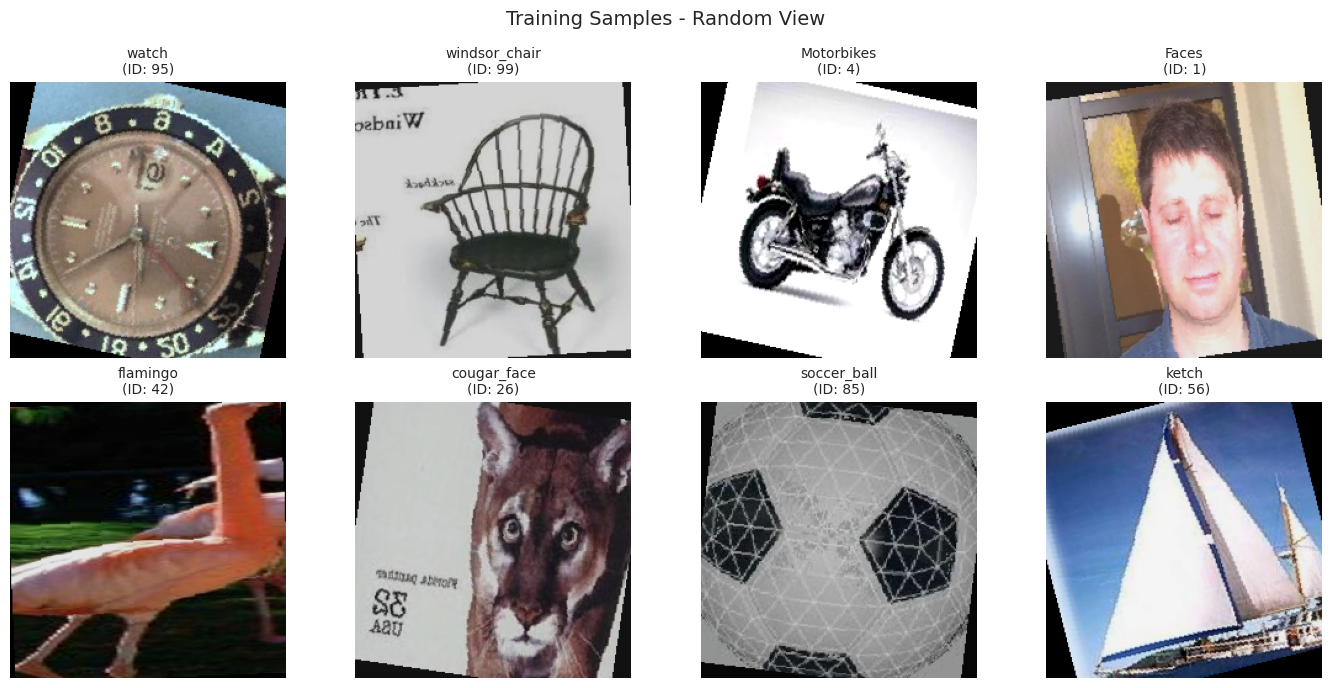

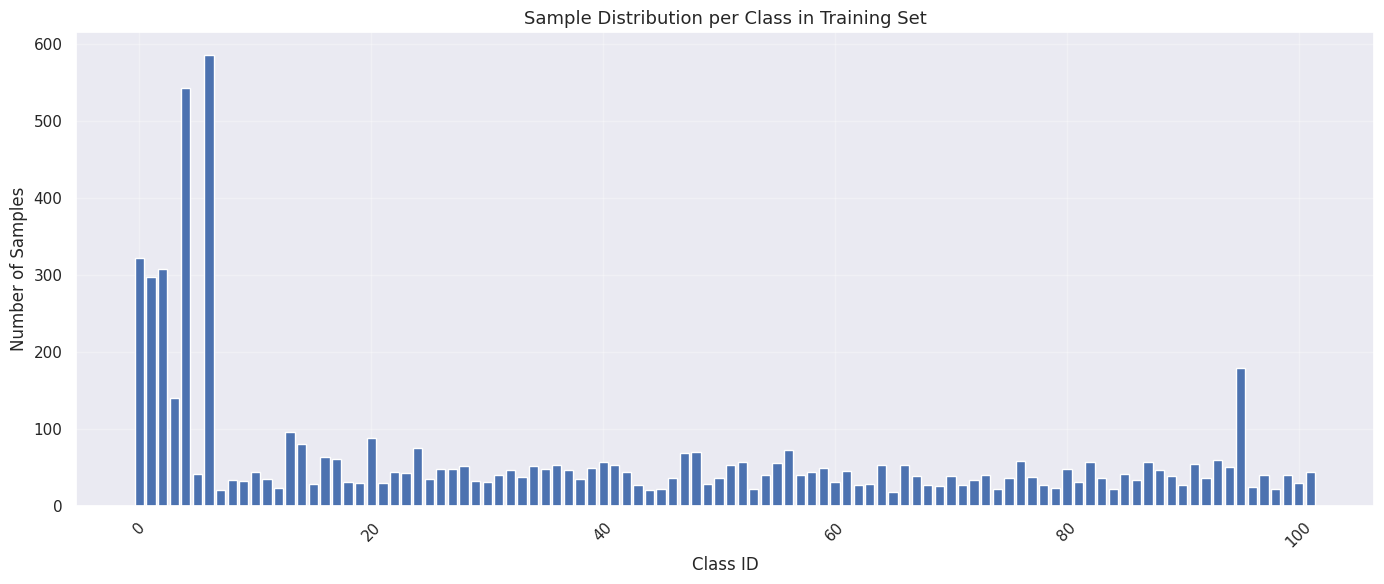

最少样本数: 19
最多样本数: 586
平均样本数: 62.7


In [24]:
# 可视化样本图像和类别分布
print("可视化样本数据...")

# 获取一个批次的样本
images, labels = next(iter(train_loader))

# 反标准化用于显示
def denormalize(image, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """反标准化图像"""
    image = image.clone()
    for i in range(3):
        image[i] = image[i] * std[i] + mean[i]
    return image.clamp(0, 1)

# 绘制样本图像
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Training Samples - Random View', fontsize=14)

for idx, ax in enumerate(axes.flat):
    img = denormalize(images[idx])
    img = img.permute(1, 2, 0).numpy()
    class_name = full_dataset.classes[labels[idx]]
    
    ax.imshow(img)
    ax.set_title(f'{class_name}\n(ID: {labels[idx]})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 绘制类别分布
class_distribution = np.zeros(num_classes)
for images, labels in train_loader:
    for label in labels:
        class_distribution[label] += 1

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(num_classes), class_distribution)
ax.set_xlabel('Class ID', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Sample Distribution per Class in Training Set', fontsize=13)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"最少样本数: {int(class_distribution.min())}")
print(f"最多样本数: {int(class_distribution.max())}")
print(f"平均样本数: {class_distribution.mean():.1f}")

## 3. Vision Transformer (ViT) 设计哲学与核心架构

在开始训练之前，我们需要理清 ViT 的内部构造流程。它彻底颠覆了卷积核提取特征的思路。

### 3.1 图像到序列的转变：Patching
*   **图像并不是像素的集合，而是语义碎片的序列**。
*   输入图像 $1 \times 3 \times 224 \times 224$ 被打散成 $196$ 个 $16 \times 16$ 的 Patch。
*   每个 Patch 相当于一个“词”，通过线性映射转化为 $768$ 维的向量。

### 3.2 Transformer Encoder 的工作流程
1.  **多头自注意力 (Multi-Head Self-Attention, MHSA)**: 允许模型在同一时间关注图像的不同部分。例如，在识别“汽车”时，模型可能同时关注轮子和挡风玻璃。
2.  **前馈网络 (FFN)**: 对每个位置的特征进行深度非线性变换，通常由两个全连接层组成。
3.  **残差链接 (Residual Connection)**: 确保梯度能够顺利流向深层，防止网络退化。

### 3.3 [CLS] Token：全局信息的总结者
ViT 借鉴了 BERT 的做法，在输入的序列开头插入一个特殊的向量（[CLS]）。这个向量不代表任何 patch，但在经过所有 Transformer 层后，它会汇聚整张图的上下文信息。最终的**分类头 (Classifier Head)** 就挂在这个 [CLS] 向量之上。

## 4. 构建与定制 ViT 分类网络

### 策略：迁移学习 (Fine-tuning)
从零开始训练 ViT 非常困难，因为它需要数亿张图片（如 JFT-300M）。本案例中，我们将使用以下“手术式”修改方法：
1.  **加载 Base 模型**: 使用 `vit_base_patch16_224`，它包含 12 个 Transformer block，共约 86M 参数。
2.  **保留 Backbone**: 所有的预训练 Layer（提取通用视觉特征的部分）都将被保留。
3.  **重置 Head**: 原模型输出是 1000 类（ImageNet），我们要将其最后一层线性变换（Linear Layer）替换为输出 101 类。

**注意**：在下面的代码中，我们通过 `strict=False` 加载权重。这意味着模型会跳过我们刚刚修改的分类头（因为它尺寸对不上），而加载其他所有层的成熟权重。


In [25]:
# 指定本地权重路径（权重文件已放置在当前目录下）
local_weights_path = './vit_base_patch16_224.pth' 

print("正在构建模型并从本地加载权重 vit_base_patch16_224.pth...")
print("=" * 60)

# 创建模型框架，不自动下载预训练权重
model = timm.create_model('vit_base_patch16_224', 
                         pretrained=False, 
                         num_classes=num_classes)

# 检查本地权重文件是否存在
if os.path.exists(local_weights_path):
    try:
        # 加载权重
        checkpoint = torch.load(local_weights_path, map_location='cpu')
        
        # 处理可能的字典嵌套
        if isinstance(checkpoint, dict):
            if 'model' in checkpoint:
                state_dict = checkpoint['model']
            elif 'state_dict' in checkpoint:
                state_dict = checkpoint['state_dict']
            else:
                state_dict = checkpoint
        else:
            state_dict = checkpoint
            
        # 解决 head.weight 尺寸不匹配的关键步骤：
        # 由于预训练权重的分类头与我们当前的类别数不同，我们需要删除权重字典中的 head 部分
        # 这样 load_state_dict(strict=False) 就会保留我们模型初始化的新分类头
        keys_to_delete = ['head.weight', 'head.bias']
        for key in keys_to_delete:
            if key in state_dict:
                print(f"移除不匹配的权重层: {key}")
                del state_dict[key]
        
        # 加载权重
        msg = model.load_state_dict(state_dict, strict=False)
        print("本地权重加载成功！")
        
        if len(msg.missing_keys) > 0:
            print(f"注意到以下层已重置（将从头开始训练）: {msg.missing_keys}")
            
    except Exception as e:
        print(f"加载过程中出错: {e}")
        print("请检查权重文件是否完整。")
else:
    print(f"错误: 在路径 {local_weights_path} 找不到权重文件")
    print("请确保文件名为 vit_base_patch16_224.pth 且位于 25.ViT_Classification 目录下")

# 将模型移到计算设备
model = model.to(device)

print(f"\n计算设备: {device}")
print(f"分类任务类别数: {num_classes}")

# 计算模型参数
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
print(f"\n模型参数统计:")
print(f"  总参数数: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"  可训练参数: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print("=" * 60)

正在构建模型并从本地加载权重 vit_base_patch16_224.pth...
移除不匹配的权重层: head.weight
移除不匹配的权重层: head.bias
本地权重加载成功！
注意到以下层已重置（将从头开始训练）: ['head.weight', 'head.bias']

计算设备: cuda
分类任务类别数: 102

模型参数统计:
  总参数数: 85,877,094 (85.88M)
  可训练参数: 85,877,094 (85.88M)


## 5. 训练、验证与优化策略

### 5.1 为什么选择 AdamW？
传统的 Adam 会导致 $L_2$ 正则化失效。**AdamW (Weight Decay Fix)** 将权重衰减直接应用到更新步骤中，对于像 ViT 这种参数极其庞大的网络，AdamW 能显著降低过拟合风险。

### 5.2 学习率的余弦退火 (Cosine Annealing)
我们不使用固定步长的衰减，而是使用余弦曲线。这种策略：
*   在训练初期保持较大的学习率，加快收敛。
*   在训练后期平滑地降低到接近零，帮助模型在全局最优值附近进行细微震荡，捕捉最优解。

### 5.3 训练逻辑
我们将每一个 Epoch 分为两个行动：
1.  **Train Phase**: 开启梯度计算，执行反向传播，更新模型参数。
2.  **Validation Phase**: 关闭梯度（省内存），测试模型在未见过的数据上的预测力。如果验证集得分提升，我们就保存该时刻的参数。


In [26]:
# 定义训练参数
num_epochs = 5
learning_rate = 1e-4
weight_decay = 1e-4

# 定义损失函数
criterion = nn.CrossEntropyLoss()

# 定义优化器 (AdamW)
optimizer = optim.AdamW(model.parameters(), 
                        lr=learning_rate, 
                        weight_decay=weight_decay)

# 定义学习率调度器 (CosineAnnealingLR)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

print("训练配置:")
print(f"  Epoch数: {num_epochs}")
print(f"  学习率: {learning_rate}")
print(f"  权重衰减: {weight_decay}")
print(f"  批大小: {batch_size}")
print(f"  优化器: AdamW")
print(f"  调度器: CosineAnnealingLR")
print("=" * 60)

训练配置:
  Epoch数: 5
  学习率: 0.0001
  权重衰减: 0.0001
  批大小: 32
  优化器: AdamW
  调度器: CosineAnnealingLR


### 5.4 定义训练与验证的核心逻辑

为了让代码结构清晰且易于维护，我们将训练过程封装为两个主要函数：
*   **`train_epoch`**: 负责单轮训练。它会遍历 DataLoader 中的每一个批次，计算梯度并更新权重。
*   **`validate`**: 负责单轮评估。它会暂时关闭模型的 `Dropout` 和 `BatchNorm` 层（通过 `model.eval()`），并禁用梯度计算（通过 `torch.no_grad()`），以获取模型在当前状态下的真实准确率。

我们将在这两个函数中实时计算 Loss (损失值) 和 Accuracy (准确率)，以便后续绘制学习曲线。


In [27]:
# 定义训练函数
def train_epoch(model, train_loader, optimizer, criterion, device):
    """训练一个epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # 前向传播
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        
        # 统计
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # 打印进度
        if (batch_idx + 1) % 5 == 0:
            # 使用 sys.stdout.write 和 \r 配合，并在末尾添加空格以覆盖旧文本
            msg = f"  Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}, Acc: {correct/total*100:.2f}%"
            print(msg.ljust(60), end='\r')
    
    # 一个 epoch 结束后，打印一个换行符，防止后续输出重叠
    print()
    
    avg_loss = running_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy

# 定义验证函数
def validate(model, val_loader, criterion, device):
    """在验证集上评估模型"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_loss = running_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy

### 5.5 开始主训练循环

现在万事俱备，我们将开启正式的训练。
在每一轮 (Epoch) 结束后，我们会对比当前的验证集准确率与历史最高记录。如果当前模型表现更好，我们会保存其权重。这种**“模型持久化”**机制确保了即使训练在后期出现震荡，我们也能获得曾经达到过的最优解。

**注**：由于 ViT 模型参数量巨大，即使在有 GPU 加速的情况下，每个 Epoch 的耗时仍可能需要数分钟，请耐心等待。


In [28]:
# 初始化历史记录
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# 主训练循环
print("\n" + "=" * 60)
print("开始训练ViT模型...")
print("=" * 60 + "\n")

import time
start_time = time.time()

best_val_acc = 0
best_model_state = None

for epoch in range(num_epochs):
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    
    # 训练
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # 验证
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # 更新调度器
    scheduler.step()
    
    # 记录历史
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
    
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc*100:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}\n")

# 加载最佳模型
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"已加载最佳模型 (验证准确率: {best_val_acc*100:.2f}%)")

elapsed_time = time.time() - start_time
print(f"\n训练完成！总耗时: {elapsed_time/60:.2f} 分钟")
print("=" * 60)


开始训练ViT模型...

Epoch [1/5]
  Batch [200/200], Loss: 0.2628, Acc: 78.88%                
  Train Loss: 0.9050, Train Acc: 78.88%
  Val Loss:   0.5364, Val Acc:   85.27%
  LR: 0.000091

Epoch [2/5]
  Batch [200/200], Loss: 0.6615, Acc: 94.86%                
  Train Loss: 0.1843, Train Acc: 94.86%
  Val Loss:   0.4428, Val Acc:   89.06%
  LR: 0.000066

Epoch [3/5]
  Batch [200/200], Loss: 0.0020, Acc: 97.92%                
  Train Loss: 0.0701, Train Acc: 97.92%
  Val Loss:   0.2767, Val Acc:   92.63%
  LR: 0.000035

Epoch [4/5]
  Batch [200/200], Loss: 0.0023, Acc: 99.14%                
  Train Loss: 0.0245, Train Acc: 99.14%
  Val Loss:   0.2111, Val Acc:   93.87%
  LR: 0.000010

Epoch [5/5]
  Batch [200/200], Loss: 0.0016, Acc: 99.69%                
  Train Loss: 0.0097, Train Acc: 99.69%
  Val Loss:   0.1940, Val Acc:   94.60%
  LR: 0.000001

已加载最佳模型 (验证准确率: 94.60%)

训练完成！总耗时: 5.14 分钟


### 5.6 学习曲线可视化

训练完成后的第一件事是查看**损失 (Loss)** 和 **准确率 (Accuracy)** 曲线。
*   如果 Loss 持续下降且 Acc 持续上升，说明模型正在有效学习。
*   如果训练集 Acc 极高而验证集 Acc 停滞不前，说明出现了**过拟合 (Overfitting)**。
*   通过观察曲线的斜率，我们可以判断训练是否已经收敛，或者是否需要增加训练轮数。


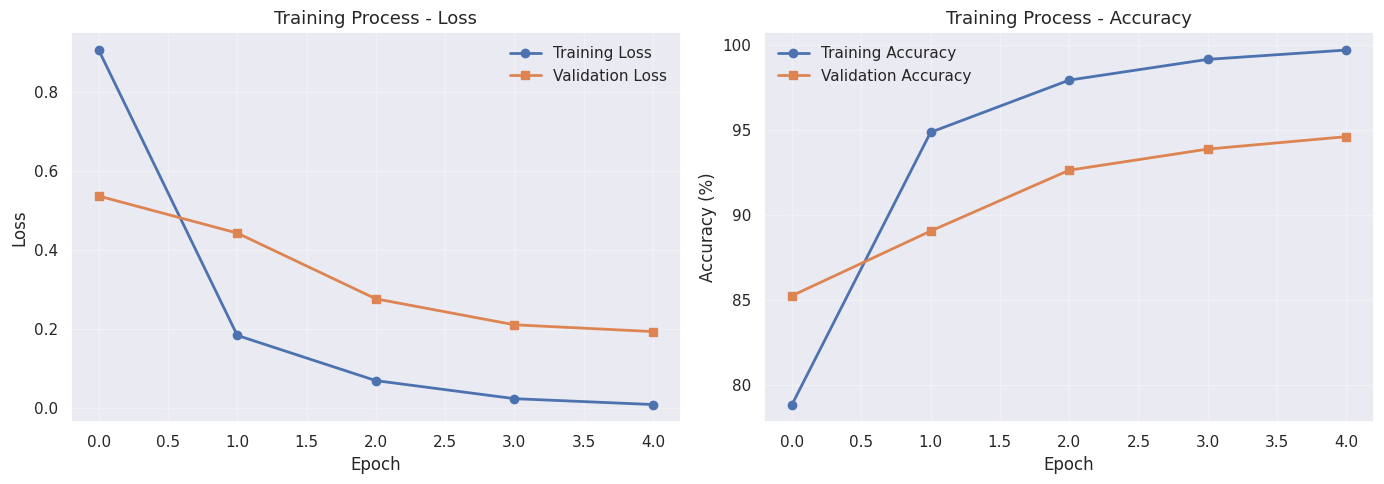

训练过程统计:
  初始训练准确率: 78.88%
  最终训练准确率: 99.69%
  初始验证准确率: 85.27%
  最佳验证准确率: 94.60%


In [29]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 绘制损失曲线
axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2, marker='o')
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Process - Loss', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# 绘制准确率曲线
axes[1].plot([x*100 for x in history['train_acc']], label='Training Accuracy', linewidth=2, marker='o')
axes[1].plot([x*100 for x in history['val_acc']], label='Validation Accuracy', linewidth=2, marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training Process - Accuracy', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("训练过程统计:")
print(f"  初始训练准确率: {history['train_acc'][0]*100:.2f}%")
print(f"  最终训练准确率: {history['train_acc'][-1]*100:.2f}%")
print(f"  初始验证准确率: {history['val_acc'][0]*100:.2f}%")
print(f"  最佳验证准确率: {max(history['val_acc'])*100:.2f}%")

## 6. 模型评估与深度诊断

一个好的 AI 工程师不应只关注最终的“平均准确率”。我们需要透视模型内部的偏见：
1.  **Macro vs Weighted Metrics**: 针对 Caltech101 这种类别不平衡的长尾分布，Macro 分数（简单平均）能如实反映模型在小众类别上的表现。
2.  **混淆矩阵 (Confusion Matrix)**: 它是模型的“错题集”。例如，它是否经常把“大象”误认为“犀牛”？这能帮助我们判断是数据太像了，还是模型特征提取能力不够。
3.  **结果可视化**: 直观观察模型对哪些图信心十足（Confidence 高），对哪些图犹豫不决。

接下来的分析将揭示 ViT 在 Caltech101 上的真实底力。


In [30]:
# 在测试集上测试
print("=" * 60)
print("在测试集上评估模型性能...")
print("=" * 60 + "\n")

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.concatenate(all_probs, axis=0)

# 计算整体准确率
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"测试集准确率: {test_accuracy*100:.2f}%")

# 计算每类的性能指标
print("\n各类别的性能指标 (前20类):")
print("=" * 60)

class_report = classification_report(all_labels, all_preds, 
                                     target_names=full_dataset.classes,
                                     digits=4, output_dict=True)

# 创建性能表格
performance_data = []
for i, class_name in enumerate(full_dataset.classes[:20]):
    if str(i) in class_report:
        metrics = class_report[str(i)]
        performance_data.append({
            'Class': class_name,
            'Precision': f"{metrics['precision']:.4f}",
            'Recall': f"{metrics['recall']:.4f}",
            'F1-Score': f"{metrics['f1-score']:.4f}",
            'Samples': int(metrics['support'])
        })

performance_df = pd.DataFrame(performance_data)
print(performance_df.to_string(index=False))

# 宏平均和微平均
print("\n聚合性能指标:")
print(f"  Macro Precision: {class_report['macro avg']['precision']:.4f}")
print(f"  Macro Recall: {class_report['macro avg']['recall']:.4f}")
print(f"  Macro F1-Score: {class_report['macro avg']['f1-score']:.4f}")
print(f"  Weighted F1-Score: {class_report['weighted avg']['f1-score']:.4f}")

在测试集上评估模型性能...



测试集准确率: 94.97%

各类别的性能指标 (前20类):
Empty DataFrame
Columns: []
Index: []

聚合性能指标:
  Macro Precision: 0.9298
  Macro Recall: 0.9283
  Macro F1-Score: 0.9233
  Weighted F1-Score: 0.9496


### 6.2 混淆矩阵与长尾类别表现深度解析

对于一个 101 类的分类器，总准确率可能会掩盖某些细节。例如，模型可能在样本数极多的“人脸”类上表现完美，但在只有几十张图的小众类上表现糟糕。

接下来我们将通过以下方式进行定性分析：
1.  **混淆矩阵 (Confusion Matrix)**: 直观展示模型最容易在哪些类别之间产生混淆。
2.  **Top/Bottom 准确率分析**: 找出模型识别效果最好和最差的 10 个类别。这往往能揭示图像背景过于复杂或物体特征不够明显的深层原因。
    *   *例如：模型是否在背景相似的“风景”和“自然景观”间犹豫不决？*



计算混淆矩阵...


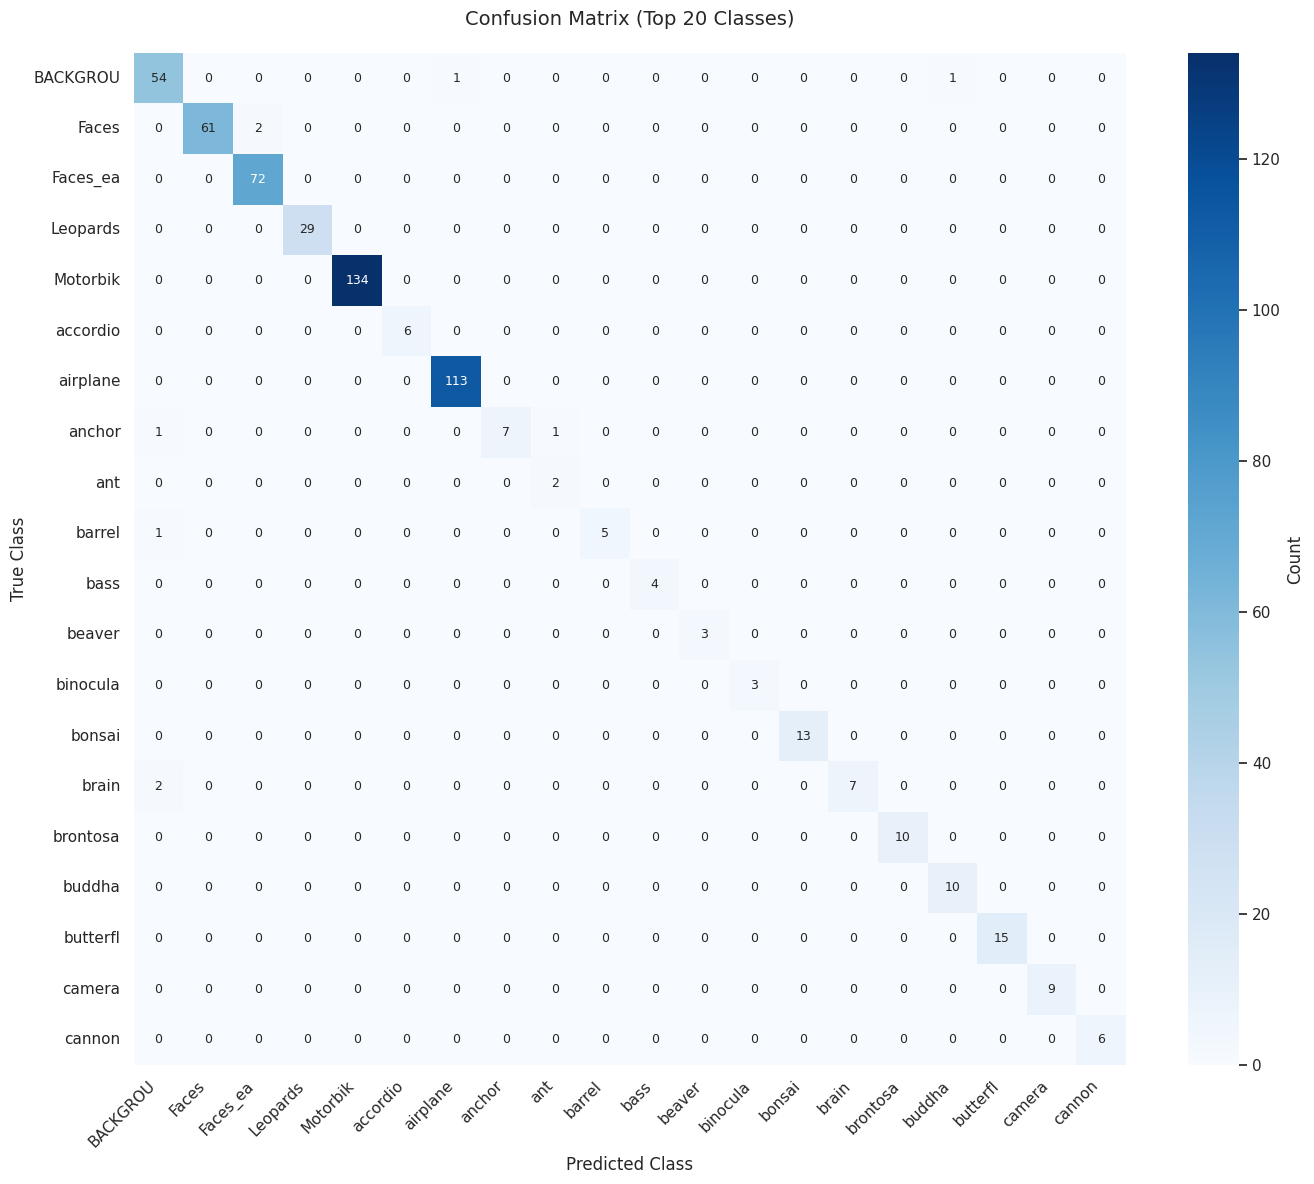


各类别的识别准确率:

识别效果最好的10个类别:
   1. Faces_easy           - 准确率: 100.00% (样本数: 72)
   2. Leopards             - 准确率: 100.00% (样本数: 29)
   3. Motorbikes           - 准确率: 100.00% (样本数: 134)
   4. accordion            - 准确率: 100.00% (样本数: 6)
   5. airplanes            - 准确率: 100.00% (样本数: 113)
   6. ant                  - 准确率: 100.00% (样本数: 2)
   7. bass                 - 准确率: 100.00% (样本数: 4)
   8. binocular            - 准确率: 100.00% (样本数: 3)
   9. bonsai               - 准确率: 100.00% (样本数: 13)
  10. buddha               - 准确率: 100.00% (样本数: 10)

识别效果最差的10个类别:
   1. lotus                - 准确率:  77.78% (样本数: 9)
   2. crab                 - 准确率:  75.00% (样本数: 8)
   3. platypus             - 准确率:  71.43% (样本数: 7)
   4. mandolin             - 准确率:  70.00% (样本数: 10)
   5. garfield             - 准确率:  66.67% (样本数: 3)
   6. anchor               - 准确率:  63.64% (样本数: 11)
   7. octopus              - 准确率:  60.00% (样本数: 5)
   8. wild_cat             - 准确率:  57.14% (样本数: 7)
   9. beaver               - 准

In [31]:
# 计算并可视化混淆矩阵（仅显示前20个类别以便查看）
print("\n计算混淆矩阵...")
cm_full = confusion_matrix(all_labels, all_preds)

# 仅显示前20个类别
class_subset_size = min(20, num_classes)
cm_subset = cm_full[:class_subset_size, :class_subset_size]

fig, ax = plt.subplots(figsize=(14, 12))
# 将 annot=False 改为 True，以显示矩阵中的数字
sns.heatmap(cm_subset, 
            xticklabels=[full_dataset.classes[i][:8] for i in range(class_subset_size)],  # 截短类名
            yticklabels=[full_dataset.classes[i][:8] for i in range(class_subset_size)],
            annot=True,     # 显示数值
            fmt='d',        # 以整数格式显示
            annot_kws={'size': 9}, # 设置字体大小以适应格子
            cmap='Blues',
            ax=ax,
            cbar_kws={'label': 'Count'})

ax.set_title(f'Confusion Matrix (Top {class_subset_size} Classes)', fontsize=14, pad=20)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 计算类别准确率
class_accuracies = []
print("\n各类别的识别准确率:")
print("=" * 60)
for i in range(num_classes):
    class_mask = all_labels == i
    if class_mask.sum() > 0:
        class_acc = (all_preds[class_mask] == i).sum() / class_mask.sum()
        class_accuracies.append((full_dataset.classes[i], class_acc, class_mask.sum()))

# 按准确率排序
class_accuracies.sort(key=lambda x: x[1], reverse=True)

# 显示排名前10和后10
print("\n识别效果最好的10个类别:")
for i, (class_name, acc, count) in enumerate(class_accuracies[:10], 1):
    print(f"  {i:2d}. {class_name:20s} - 准确率: {acc*100:6.2f}% (样本数: {int(count)})")

print("\n识别效果最差的10个类别:")
for i, (class_name, acc, count) in enumerate(class_accuracies[-10:], 1):
    print(f"  {i:2d}. {class_name:20s} - 准确率: {acc*100:6.2f}% (样本数: {int(count)})")

### 6.3 直观结论：测试样本结果对比

最后，我们将通过一组可视化结果来直观感受模型的“眼力”。
我们将从测试集中随机抽取一组图像，对比它们的**真实标签 (True Label)** 与 **模型预测 (Pred Label)**。
*   **绿色标题**: 代表预测正确，同时显示其置信度 (Confidence)。
*   **红色标题**: 代表预测错误，我们可以借此观察模型究竟被图像中的哪些特征“误导”了。



可视化模型预测...


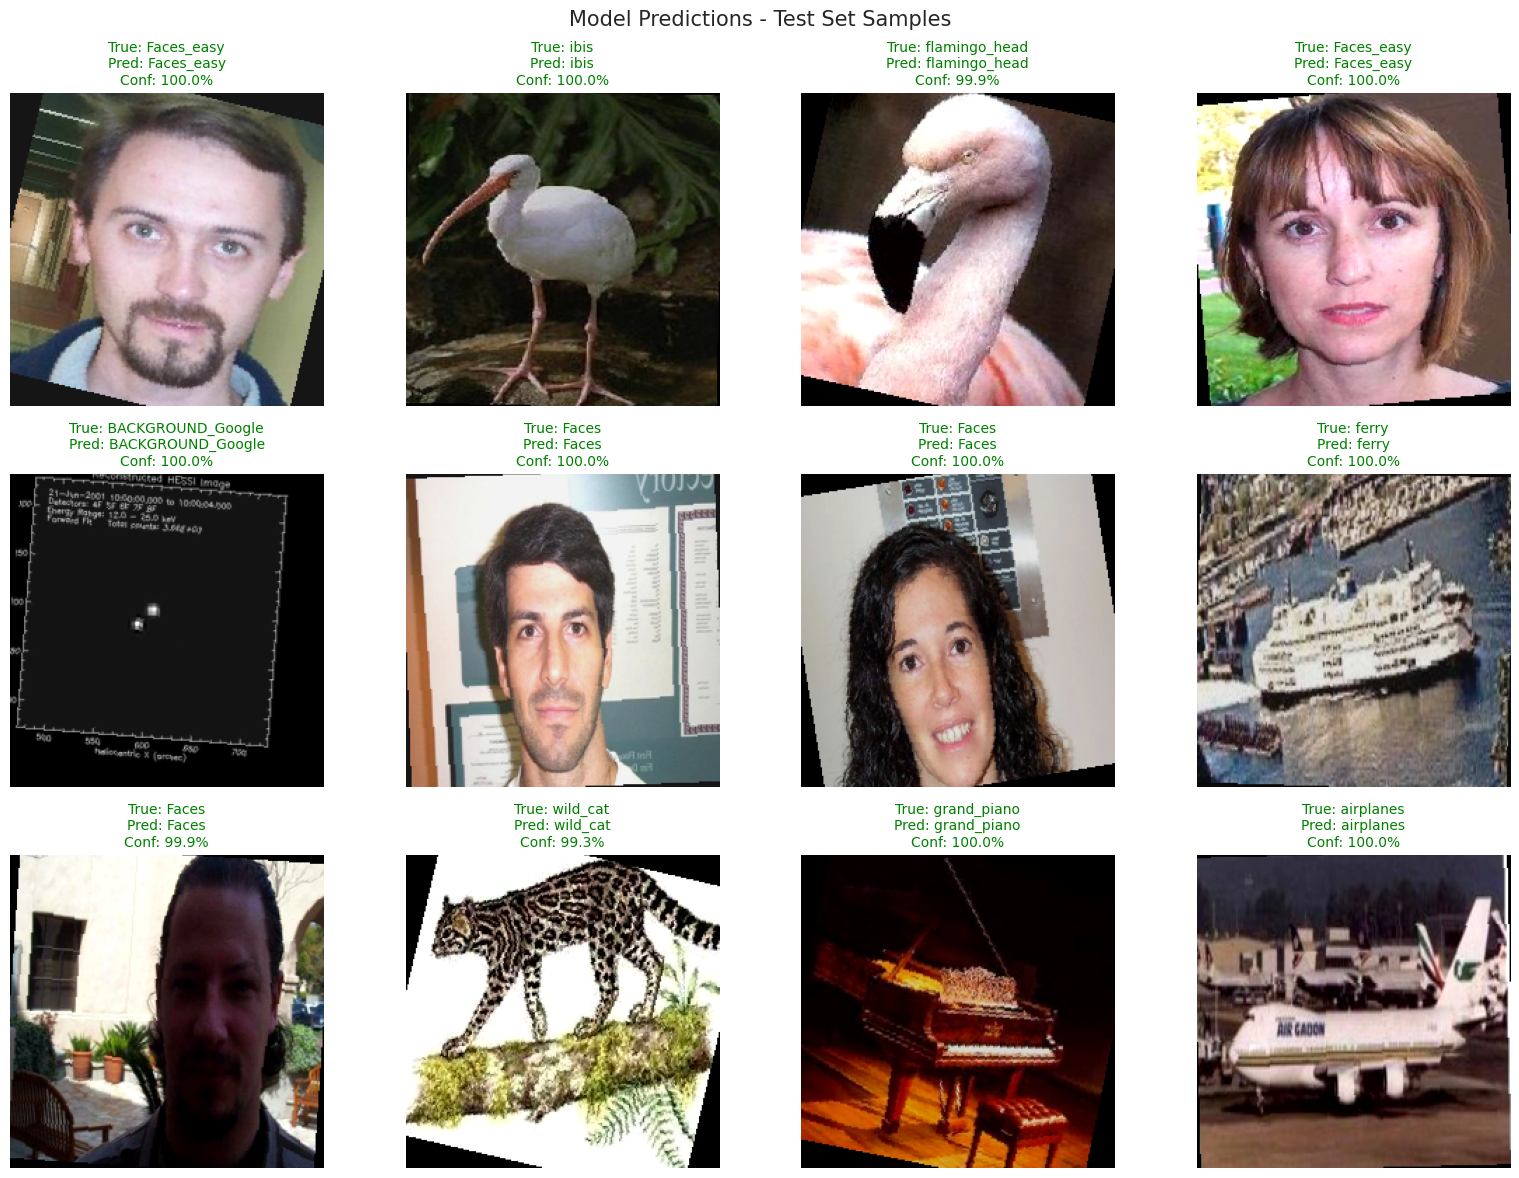

In [32]:
# 可视化预测结果
print("\n可视化模型预测...")

# 获取一个批次的测试样本
test_images, test_labels = next(iter(test_loader))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Model Predictions - Test Set Samples', fontsize=15)

model.eval()
with torch.no_grad():
    test_images_gpu = test_images.to(device)
    outputs = model(test_images_gpu)
    probs = F.softmax(outputs, dim=1)
    _, predictions = torch.max(outputs, 1)

for idx, ax in enumerate(axes.flat):
    # 反标准化并显示图像
    img = denormalize(test_images[idx])
    img = img.permute(1, 2, 0).numpy()
    
    true_label = full_dataset.classes[test_labels[idx]]
    pred_label = full_dataset.classes[predictions[idx]]
    confidence = probs[idx].max().item() * 100
    
    # 判断预测是否正确
    is_correct = predictions[idx] == test_labels[idx]
    color = 'green' if is_correct else 'red'
    
    ax.imshow(img)
    title = f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'
    ax.set_title(title, fontsize=10, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. 拓展思考：深度理解 ViT Backbone

在之前的实战中，我们通过 `timm` 库直接调用了预置好的 ViT backbone。为了更透彻地理解它的工作机制，请思考并尝试回答以下核心问题。

### 思考题：如何手动编写 Vision Transformer 的主干网络 (Backbone)？

**学习目标**：掌握 ViT 模型中从输入图像到特征表示（Representation）的核心代码逻辑。

**参考答案**：
一个标准的 ViT Backbone 主要由三个部分构成：**Patch Embedding (分块嵌入)**、**Positional Encoding (位置编码)** 以及 **Transformer Encoder Layers (编码器层)**。

以下是一个简化版的 Python 代码实现，展示了其核心结构：

```python
import torch
import torch.nn as nn

class SimplifiedViTBackbone(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768, depth=12, num_heads=12):
        super().__init__()
        # 1. Patch Embedding: 使用卷积层实现（这是业界常用技巧）
        self.patch_embed = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        
        num_patches = (img_size // patch_size) ** 2
        
        # 2. CLS Token: 一个可学习的参数，放在序列开头
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # 3. Position Embedding: 为每个 patch + cls_token 准备位置信息
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        
        # 4. Transformer Blocks: 堆叠多层 Transformer 编码器
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim, 
                nhead=num_heads, 
                dim_feedforward=embed_dim * 4, 
                activation='gelu',
                batch_first=True
            ) for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: [B, 3, 224, 224]
        # Step 1: 图像分块并映射 [B, 768, 14, 14] -> flatten -> [B, 768, 196] -> transpose -> [B, 196, 768]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        
        # Step 2: 拼凑 CLS Token [B, 1, 768]
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  # [B, 197, 768]
        
        # Step 3: 加上位置编码
        x = x + self.pos_embed
        
        # Step 4: 穿过所有 Transformer 层
        for block in self.blocks:
            x = block(x)
        
        # Step 5: Layer Normalization
        x = self.norm(x)
        
        # 输出 CLS Token 的特征作为 Backbone 的最终表示
        return x[:, 0]

# 实例化
backbone = SimplifiedViTBackbone()
sample_input = torch.randn(1, 3, 224, 224)
features = backbone(sample_input)
print(f"输入形状: {sample_input.shape}")
print(f"Backbone 输出特征形状: {features.shape}") # 应为 [1, 768]
```

**关键点总结**：
1.  **Conv2d 技巧**：在代码实现中，我们通常用卷积核大小等于步长的卷积层来高效地完成“图像切块+投影”的操作。
2.  **序列拼接**：注意 `cls_token` 的引入以及它在序列中的主导地位。
3.  **维度对齐**：理解 `pos_embed` 是如何通过加法（Addition）而非拼接（Concatenation）融入序列的。
---
